In [1]:
import pandas as pd
import numpy as np
import random

In [2]:
sensitive_boundaries_results_path = "/scratch1/smaruj/sensitive_boundary_results.tsv"

In [3]:
df = pd.read_csv(sensitive_boundaries_results_path, sep="\t")

In [4]:
import ast

In [5]:
df["disrupted_bin"] = df["disrupted_bin"].apply(ast.literal_eval)

In [7]:
df

,chrom,start,end,window_end,window_start,disrupted_bin,SCD,RUQ_mean
0,chr1,4400000,4410000,5061504,3750784,[261],2.120519,0.000731
1,chr1,4770000,4780000,5431504,4120784,"[252, 243, 253, 258]",14.721539,0.017108
2,chr1,5150000,5160000,5811504,4500784,"[247, 269]",3.607144,0.001020
3,chr1,5900000,5910000,6561504,5250784,"[255, 260]",11.613214,-0.019208
4,chr1,6190000,6200000,6851504,5540784,[253],6.115497,0.009087
...,...,...,...,...,...,...,...,...
3910,chr9,121450000,121460000,122111504,120800784,"[257, 266, 267]",8.670380,0.015198
3911,chr9,121700000,121710000,122361504,121050784,"[251, 243]",8.649242,0.008415
3912,chr9,122350000,122360000,123011504,121700784,[253],39.628345,-0.042670
3913,chr9,122720000,122730000,123381504,122070784,"[257, 261]",3.258348,-0.004068


In [8]:
filtered_sorted_neg_df = (
    df[df["RUQ_mean"] < 0]
    .sort_values(by="RUQ_mean")
    .reset_index(drop=True)
)

In [ ]:
# filtered_sorted_pos_df = (
#     df[df["DeltaBoundaryStrength"] >= 0]
#     .sort_values(by="DeltaBoundaryStrength")
#     .reset_index(drop=True)
# )

In [9]:
to_check = filtered_sorted_neg_df[:10]

In [10]:
to_check

,chrom,start,end,window_end,window_start,disrupted_bin,SCD,RUQ_mean
0,chr13,53770000,53780000,54431504,53120784,"[255, 259, 250]",55.537971,-0.142136
1,chr5,5470000,5480000,6131504,4820784,"[258, 264]",54.602184,-0.128920
2,chr18,76350000,76360000,77011504,75700784,"[252, 264, 265, 267]",51.467289,-0.128222
3,chr5,98340000,98350000,99001504,97690784,"[247, 255, 257, 264]",46.194641,-0.115002
4,chr1,7230000,7240000,7891504,6580784,[247],50.234745,-0.112513
5,chr14,66350000,66360000,67011504,65700784,"[257, 266]",66.323311,-0.108311
6,chr4,118980000,118990000,119641504,118330784,"[253, 257, 258, 265]",61.997997,-0.106451
7,chr2,171410000,171420000,172071504,170760784,[256],44.731640,-0.091838
8,chr13,74310000,74320000,74971504,73660784,"[256, 248, 241, 268]",35.327297,-0.088790
9,chr3,44910000,44920000,45571504,44260784,"[254, 256, 266]",46.903435,-0.085770


In [11]:
from pyfaidx import Fasta

In [13]:
fasta_file = "/project/fudenber_735/genomes/mm10/mm10.fa"

In [14]:
genome = Fasta(fasta_file)

In [15]:
def one_hot_encode_sequence(sequence_obj):
    # Convert pyfaidx.Sequence object to string
    sequence = str(sequence_obj).upper()
    
    # Define the mapping from bases to integers
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    valid_bases = list(base_to_int.keys())

    # Step 1: Convert sequence to integer encoding with random base for 'N'
    encoded_indices = []
    for base in sequence:
        if base in base_to_int:
            encoded_indices.append(base_to_int[base])
        else:
            random_base = random.choice(valid_bases)
            encoded_indices.append(base_to_int[random_base])

    # Step 2: One-hot encode the sequence
    encoded_sequence = np.array(encoded_indices)
    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    # Step 3: Expand dimensions to [1, 4, sequence_length]
    # input_sequence = np.expand_dims(one_hot_encoded, axis=0)

    return one_hot_encoded

In [16]:
from torch.utils.data import Dataset
import torch

In [17]:
def permute_disrupted_bins(seq, row, bin_size=2048, cropping=64):
    # Make seq mutable
    seq = list(seq)
    
    for bin_idx in row["disrupted_bin"]:
        start = (bin_idx + cropping) * bin_size
        end = start + bin_size
        if end > len(seq):  # Avoid index error
            continue
        region = seq[start:end]
        np.random.shuffle(region)
        seq[start:end] = region  # Replace with shuffled region

    return ''.join(seq)

In [18]:
class GenomicSequenceDataset(Dataset):
    def __init__(self, coord_df, genome_fasta, transform_fn=None):
        self.coords = coord_df  # DataFrame with chrom, start, end
        self.genome = genome_fasta
        self.transform_fn = transform_fn  # Optional function to modify sequence

    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        TARGET_LEN = 1310720
        
        row = self.coords.iloc[idx]
        chrom, start, end = row["chrom"], row["window_start"], row["window_end"]
        seq = self.genome[chrom][start:end].seq.upper()
        
        # Fix sequence length if needed
        if len(seq) != TARGET_LEN:
            seq = seq[:TARGET_LEN].ljust(TARGET_LEN, 'N')  # pad with Ns if needed
        
        # Apply transformation, e.g. permute a window
        if self.transform_fn is not None:
            seq = self.transform_fn(seq, row)  # Pass row in case you want loc info
        
        one_hot = one_hot_encode_sequence(seq)  # shape: (4, L)
        return torch.from_numpy(one_hot.copy())

In [19]:
from torch.utils.data import DataLoader

In [20]:
# Original dataset
orig_dataset = GenomicSequenceDataset(to_check, genome)

# Modified (permuted) dataset
perm_dataset = GenomicSequenceDataset(to_check, genome, transform_fn=permute_disrupted_bins)

orig_loader = DataLoader(orig_dataset, batch_size=10, shuffle=False)
perm_loader = DataLoader(perm_dataset, batch_size=10, shuffle=False)

In [21]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

# from model import SeqNN
from model_v2_compatible import SeqNN

In [22]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(device)

cuda:0


In [23]:
model = SeqNN()
model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_finetuned_correctly.pt", map_location=device))
model.eval()

/tmp/SLURM_931841/ipykernel_1862513/2744654124.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_f

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [24]:
import numpy as np
import torch

def set_diag(matrix, value, k):
    """Set diagonal `k` of a matrix to `value`."""
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu_batch(batch_vectors, matrix_len=512, num_diags=2):
    """Convert a batch of upper-triangular vectors into symmetric matrices with np.nan on diagonals."""
    if isinstance(batch_vectors, torch.Tensor):
        batch_vectors = batch_vectors.detach().cpu().numpy()

    batch_size = batch_vectors.shape[0]
    matrices = np.zeros((batch_size, matrix_len, matrix_len), dtype=np.float32)

    triu_indices = np.triu_indices(matrix_len, num_diags)

    for i in range(batch_size):
        matrices[i][triu_indices] = batch_vectors[i]
        # Mirror to lower triangle
        matrices[i] = matrices[i] + matrices[i].T

        # Set diagonals to np.nan
        for k in range(-num_diags + 1, num_diags):
            set_diag(matrices[i], np.nan, k)

    return matrices  # shape: [B, 512, 512]

In [25]:
orig_preds_all = []
perm_preds_all = []

results = []

with torch.no_grad():
    for orig_batch, perm_batch in zip(orig_loader, perm_loader):
        orig_preds = model(orig_batch.to(device)).cpu()
        perm_preds = model(perm_batch.to(device)).cpu()
        
        scd = torch.sqrt(0.5 * ((perm_preds - orig_preds) ** 2).sum(dim=(1, 2)))
        print(scd)
        
        maps = from_upper_triu_batch(orig_preds - perm_preds)
        boundary_strength = np.nanmean(maps[:, 0:256, 256:512], axis=(1, 2))  # shape: [B]
        
        orig_preds_all.append(orig_preds)
        perm_preds_all.append(perm_preds)
        
        # Combine into results
        for i in range(len(scd)):
            results.append({
                "SCD": scd[i].item(),
                "DeltaBoundaryStrength": boundary_strength[i]
            })
        
        

tensor([43.8908, 38.5117, 57.0673, 55.4853, 19.0470, 29.4478, 36.3838,  7.7746,
        48.7075, 17.4271])


In [26]:
orig_preds_all = torch.cat(orig_preds_all, dim=0)
perm_preds_all = torch.cat(perm_preds_all, dim=0)

In [27]:
results_df = pd.DataFrame(results)

In [ ]:
results_df

In [28]:
# Helper function to set diagonal elements to a specific value
def set_diag(matrix, value, k):
    # Explicitly set the diagonal to 'value' (in this case, np.nan) for each k
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu(vector_repr, matrix_len, num_diags):
    # Ensure vector_repr is a NumPy array (if it's a PyTorch tensor, convert it)
    if isinstance(vector_repr, torch.Tensor):
        vector_repr = vector_repr.detach().flatten().cpu().numpy()  # Flatten and convert to NumPy array

    # Initialize a zero matrix of shape (matrix_len, matrix_len)
    z = np.zeros((matrix_len, matrix_len))

    # Get the indices for the upper triangular matrix
    triu_tup = np.triu_indices(matrix_len, num_diags)

    # Assign the values from the vector_repr to the upper triangular part of the matrix
    z[triu_tup] = vector_repr

    # Set the diagonals specified by num_diags to np.nan
    for i in range(-num_diags + 1, num_diags):
        set_diag(z, np.nan, i)

    # Ensure the matrix is symmetric
    return z + z.T

In [29]:
import matplotlib.pyplot as plt

0


<Figure size 500x500 with 0 Axes>

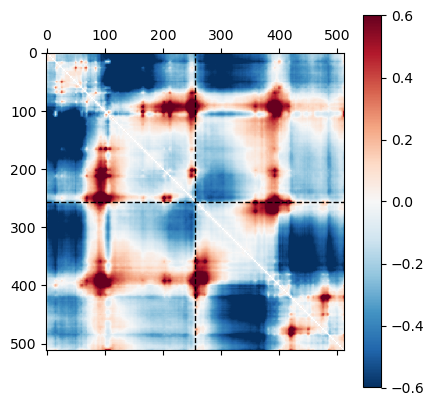

1


<Figure size 500x500 with 0 Axes>

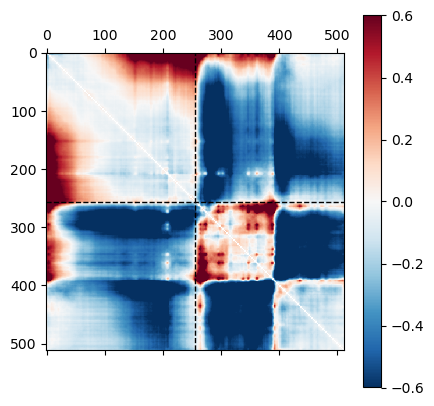

2


<Figure size 500x500 with 0 Axes>

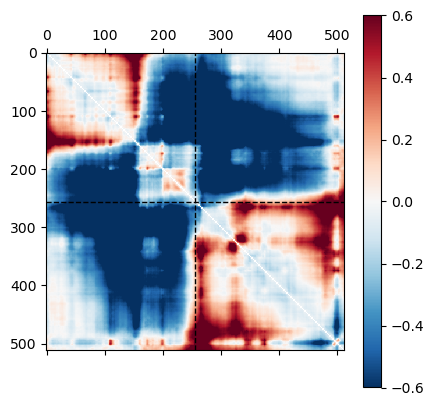

3


<Figure size 500x500 with 0 Axes>

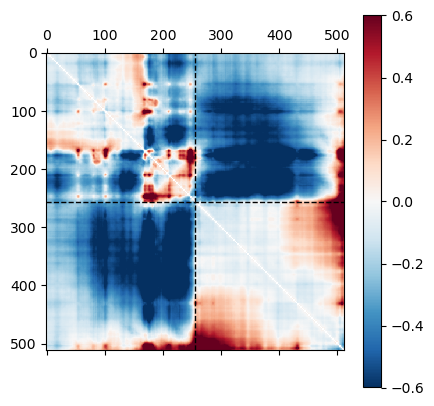

4


<Figure size 500x500 with 0 Axes>

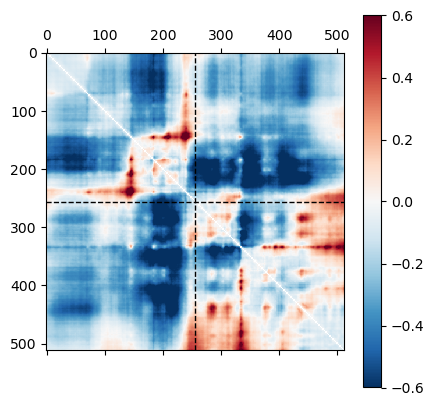

5


<Figure size 500x500 with 0 Axes>

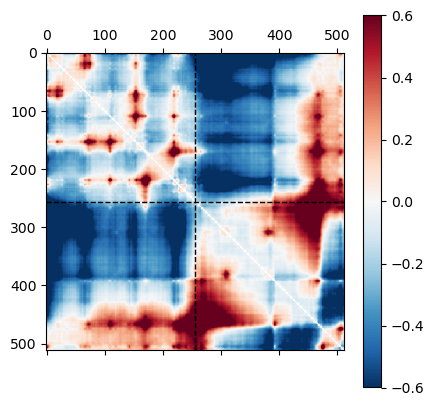

6


<Figure size 500x500 with 0 Axes>

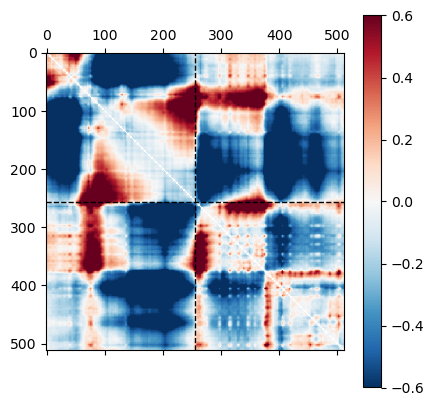

7


<Figure size 500x500 with 0 Axes>

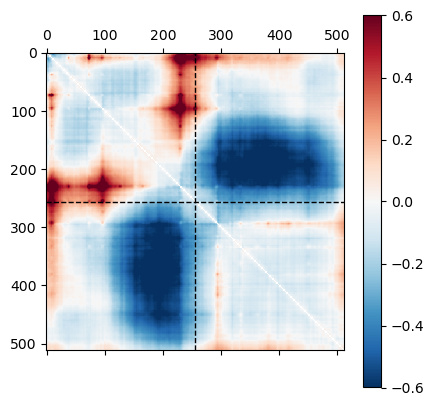

8


<Figure size 500x500 with 0 Axes>

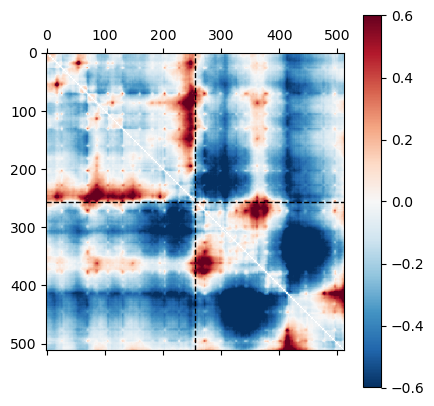

9


<Figure size 500x500 with 0 Axes>

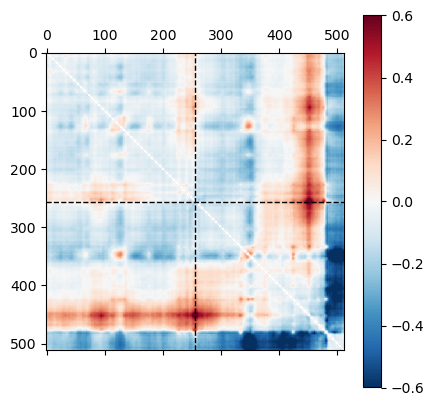

In [30]:
for i in range(10):
    print(i)
    matrix = from_upper_triu(orig_preds_all[i,:,:], matrix_len=512, num_diags=2)
    
    plt.figure(figsize=(5, 5))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    plt.axhline(256, color='black', linestyle='--', linewidth=1)
    plt.axvline(256, color='black', linestyle='--', linewidth=1)
    plt.colorbar()
    plt.show()
    

In [ ]:
for i in range(10):
    print(i)
    matrix = from_upper_triu(perm_preds_all[i,:,:], matrix_len=512, num_diags=2)
    
    plt.figure(figsize=(5, 5))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    plt.axhline(256, color='black', linestyle='--', linewidth=1)
    plt.axvline(256, color='black', linestyle='--', linewidth=1)
    plt.colorbar()
    plt.show()

In [ ]:
for i in range(10):
    print(i)
    matrix = from_upper_triu(orig_preds_all[i,:,:] - perm_preds_all[i,:,:], matrix_len=512, num_diags=2)
    
    plt.figure(figsize=(5, 5))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    plt.axhline(256, color='black', linestyle='--', linewidth=1)
    plt.axvline(256, color='black', linestyle='--', linewidth=1)
    plt.colorbar()
    plt.show()